## Import the libraries. In case of a failed import, instal the specific library

In [11]:
import os
from pytorch_fid import fid_score
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
import random
import shutil
import tempfile
from tqdm import tqdm
import matplotlib.pyplot as plt

## The ground truth and GAN-generated images' directory

In [2]:
real = './Hijja Edited/Hijja Edited'
generated = './Generated/BCE'

## The Fréchet Inception Distance (FID) score is a metric used to evaluate the quality and diversity of images generated by AI models, such as GANs or diffusion models. It is calculated on a batch of images. For this purpose, we are using PyTorch for calculating the FID and the model weights used are of the 'Inception' Model.

## The Structural Similarity Index Measure (SSIM) is a perceptual metric used to quantify the degradation of image quality, typically by comparing a processed or compressed image to an original reference image. For this purpose, we compare each real image one-by-one to each generated image to get the average score. Though, PSNR or MSE would be a better metric but this is also valuable.

## The generated images for each class are 2008 while the ground truth are in the range 400-600 so the amount of images were capped at the quantity of the ground truth images by randomly picking the corresponding generated images for both the scores.

In [3]:
def fid(real, generated, classes):
    fid_results = {}
    for cls in tqdm(classes):
        real_path = os.path.join(real, cls)
        generated_path = os.path.join(generated, cls)
        real_images = os.listdir(real_path)
        generated_images = os.listdir(generated_path)
        sampled_generated = random.sample(generated_images, len(real_images))
        temp_dir = tempfile.mkdtemp()
        for image in sampled_generated:
            shutil.copy(os.path.join(generated_path, image), temp_dir)
        fid_value = fid_score.calculate_fid_given_paths([real_path, temp_dir], batch_size = 32, device = 'cuda', dims = 2048)
        fid_results[cls] = fid_value
        shutil.rmtree(temp_dir)
    return fid_results

def compute_ssim(real_folder, generated_folder):
    real_images = sorted(os.listdir(real_folder))
    generated_images = sorted(os.listdir(generated_folder))
    generated_images = random.sample(generated_images, len(real_images))
    scores = []
    for r, g in tqdm(zip(real_images, generated_images)):
        img1 = cv2.imread(os.path.join(real_folder, r), 0)
        img2 = cv2.imread(os.path.join(generated_folder, g), 0)
        img1 = cv2.resize(img1, (32, 32))
        img2 = cv2.resize(img2, (32, 32))
        score = ssim(img1, img2)
        scores.append(score)
    return np.mean(scores)
    
def ssim_scores_images(real, generated, classes):
    ssim_results = {}
    for cls in classes:
        real_path = os.path.join(real, cls)
        generated_path = os.path.join(generated, cls)
        ssim_score = compute_ssim(real_path, generated_path)
        ssim_results[cls] = ssim_score
    return ssim_results

In [4]:
classes = os.listdir(real)

## There are 29 Arabic Alphabets which are titled 0 - 28. To get their original names, we created a dictionary mapping the number to the actual name for better representation.

In [5]:
classes_names = {'0': 'alif', '1': 'baa', '2': 'taa', '3': 'saa', '4': 'jeem', '5': 'haa',
                 '6': 'khaa', '7': 'dal', '8': 'zal', '9': 'ra', '10': 'za', '11': 'sin',
                 '12': 'shin', '13': 'sat', '14': 'zad', '15': 'tai', '16': 'zai', '17': 'ayn',
                 '18': 'gayn', '19': 'fa', '20': 'qaf', '21': 'kaf', '22': 'lam', '23': 'mim',
                 '24': 'nun', '25': 'ha', '26': 'waw', '27': 'ya', '28': 'hamza'}

## Skip till Continue

In [6]:
fid_scores = fid(real, generated, classes)

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:18<00:00,  1.24s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:17<00:00,  1.19s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:16<00:00,  1.21s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:17<00:00,  1.25s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:17<00:00,  1.24s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:17<00:00,  1.24s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:17<00:00,  1.23s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:17<00:00,  1.16s/it]

100%|███████████████████████████

In [7]:
ssim_scores = ssim_scores_images(real, generated, classes)

460it [00:07, 58.22it/s]
452it [00:07, 58.28it/s]
426it [00:07, 60.08it/s]
440it [00:07, 59.70it/s]
439it [00:07, 60.16it/s]
438it [00:07, 60.13it/s]
432it [00:07, 60.04it/s]
452it [00:07, 60.52it/s]
422it [00:06, 60.92it/s]
434it [00:07, 60.54it/s]
427it [00:07, 60.66it/s]
434it [00:07, 60.46it/s]
451it [00:07, 60.74it/s]
435it [00:07, 60.35it/s]
438it [00:07, 60.31it/s]
437it [00:07, 60.63it/s]
435it [00:07, 61.13it/s]
440it [00:07, 61.18it/s]
428it [00:07, 60.69it/s]
439it [00:07, 60.78it/s]
435it [00:07, 60.30it/s]
425it [00:06, 60.84it/s]
454it [00:07, 60.10it/s]
472it [00:07, 60.36it/s]
462it [00:07, 60.98it/s]
471it [00:07, 61.09it/s]
449it [00:07, 61.43it/s]
429it [00:07, 61.15it/s]
424it [00:07, 60.38it/s]


## Converting the dictionaries of the scores to numpy arrays for storage purposes.

In [10]:
fids = np.array(fid_scores)
ssims = np.array(ssim_scores)

In [11]:
np.save('FID_Scores.npy', fids)
np.save('SSIM_Scores.npy', ssims)

## Continue

## Loading the arrays and then picking the item stored in each array which is the corresponding dictionary.

In [12]:
fids = np.load('FID_Scores.npy', allow_pickle = True).item()
ssims = np.load('SSIM_Scores.npy', allow_pickle = True).item()

## Mapping the alphabet numbers to their respective names for better representation of the per-class scores.

In [17]:
fids_names = {}
ssims_names = {}

for key in fids.keys():
    fids_names[classes_names[key]] = fids[key]

for key in ssims.keys():
    ssims_names[classes_names[key]] = ssims[key]

In [20]:
for key in fids_names.keys():
    print(key, ':', fids_names[key], ',', ssims_names[key] * 100)

alif : 48.93895062708094 , 50.27928245568335
baa : 38.64652387745954 , 59.32180543316643
za : 38.926037960071625 , 60.316211536050716
sin : 30.91023858183877 , 55.036318387206194
shin : 36.994225208939184 , 47.8949781387625
sat : 26.488986789805764 , 56.15170570166255
zad : 29.99063356249897 , 49.239053605989646
tai : 37.45012346885143 , 56.93861524495855
zai : 42.80024963549093 , 49.52017096003814
ayn : 37.35468899820948 , 46.41912328913854
gayn : 48.825910144718364 , 40.70563758113173
fa : 35.56679196517628 , 55.82944280244697
taa : 33.79104654064409 , 56.47560943372423
qaf : 38.14683913865849 , 51.1354345062204
kaf : 34.17811568096923 , 51.70598931189255
lam : 41.42828810174282 , 58.712004125938776
mim : 52.39323035985083 , 55.60936950784462
nun : 48.295767524588314 , 55.75851957468396
ha : 39.34454876838082 , 58.13109915957405
waw : 27.4657861077077 , 65.09749071471866
ya : 42.14815998112883 , 50.95074648236299
hamza : 30.545906239427367 , 65.86565786287572
saa : 34.685008495660384

## Display images along with their SSIM and FID Scores

## It is the same as the above functions with the only difference being that 5 pairs of images (ground truth, generated) are randomly picked and then SSIM and FID are calculated for those images and they are displayed along with their respective scores. FID is calculated over a large batch of images so it's the same for all 5 pairs.

In [12]:
def show_random_pairs_with_metrics(real_folder, generated_folder, class_name, classes_names):

    real_path = os.path.join(real_folder, class_name)
    gen_path = os.path.join(generated_folder, class_name)

    real_imgs = os.listdir(real_path)
    gen_imgs = os.listdir(gen_path)

    real_sample = random.sample(real_imgs, 5)
    gen_sample = random.sample(gen_imgs, 5)

    n = min(len(real_imgs), len(gen_imgs), 50)

    real_subset = random.sample(real_imgs, n)
    gen_subset = random.sample(gen_imgs, n)

    temp_real = tempfile.mkdtemp()
    temp_gen = tempfile.mkdtemp()

    for img in real_subset:
        shutil.copy(os.path.join(real_path, img), temp_real)

    for img in gen_subset:
        shutil.copy(os.path.join(gen_path, img), temp_gen)

    fid_value = fid_score.calculate_fid_given_paths(
        [temp_real, temp_gen],
        batch_size = 16,
        device = 'cuda',
        dims = 2048
    )

    shutil.rmtree(temp_real)
    shutil.rmtree(temp_gen)

    plt.figure(figsize = (10, 12))

    for i in range(5):

        r_img = cv2.imread(os.path.join(real_path, real_sample[i]), 0)
        g_img = cv2.imread(os.path.join(gen_path, gen_sample[i]), 0)

        r_img = cv2.resize(r_img, (32, 32))
        g_img = cv2.resize(g_img, (32, 32))

        ssim_score = ssim(r_img, g_img)

        plt.subplot(5, 2, 2 * i + 1)
        plt.imshow(r_img, cmap = 'gray')
        plt.title(f"Real")
        plt.axis('off')

        plt.subplot(5, 2, 2 * i + 2)
        plt.imshow(g_img, cmap = 'gray')
        plt.title(f"Generated\nSSIM={ssim_score:.3f}\nFID(class)={fid_value:.2f}")
        plt.axis('off')

    plt.suptitle(f"Class: {classes_names[class_name]}", fontsize = 16)
    plt.tight_layout()
    plt.show()

100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.83s/it]


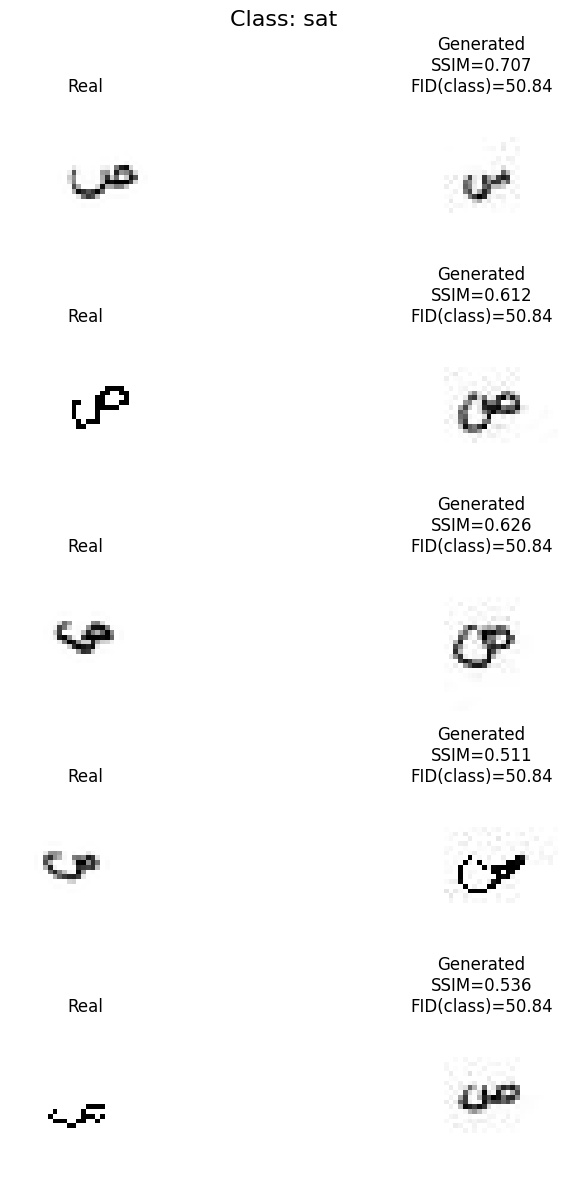

In [14]:
show_random_pairs_with_metrics(real_folder = real, generated_folder = generated, class_name = "13", classes_names = classes_names)